# US-005：ICA 伪迹去除

**目标：** 用 ICA 识别并去除眼电、心电等伪迹，获得干净脑电信号。

**关键步骤：** 预处理 → ICA 拟合 → 成分识别 → 去除 → 重建

## 1. ICA 原理速览

ICA (Independent Component Analysis) 假设观测信号是若干独立源的线性混合：
$$ X = A \cdot S $$
- $X$：观测 EEG（通道 × 时间）
- $S$：独立源（成分 × 时间）
- $A$：混合矩阵（通道 × 成分）

ICA 的目标是找到解混矩阵 $W = A^{-1}$，使得 $S = W \cdot X$

**去眼电逻辑：** 找到眼电成分 → 把对应列从 A 中删掉 → 用剩余成分重建信号。

## 2. 准备数据（含滤波预处理）

In [ ]:
import mne
import numpy as np

# 加载 sample 数据
sample_dir = mne.datasets.sample.data_path()
raw_fname = sample_dir / "MEG" / "sample" / "sample_audvis_raw.fif"
raw = mne.io.read_raw_fif(raw_fname, preload=True)

# 保留 EEG + EOG 通道（EOG 用于帮助识别眼电成分）
raw.pick_types(eeg=True, eog=True)
print(f"通道: {raw.ch_names}")

# 预处理：1Hz 高通（ICA 要求去掉慢漂移）
raw.filter(l_freq=1.0, h_freq=None)
print(f"高通滤波: {raw.info['highpass']} Hz")

## 3. 拟合 ICA

**重要：** ICA 前必须做高通滤波（≥1 Hz），否则慢漂移会占据独立成分。

In [ ]:
from mne.preprocessing import ICA

# 设置随机种子保证可复现
ica = ICA(
    n_components=20,        # 选择 20 个成分
    method='fastica',       # FastICA 算法（最常用）
    random_state=42,
    max_iter='auto',
)

# 拟合（只对 EEG 通道做 ICA，排除 EOG）
eeg_picks = mne.pick_types(raw.info, eeg=True, eog=False)
ica.fit(raw, picks=eeg_picks)
print(ica)

## 4. 识别眼电成分

### 方法一：看地形图（Topomap）
眼电成分的地形图特征：能量集中在前额，左右对称分布。

In [ ]:
# 绘制所有成分的地形图
ica.plot_components()

### 方法二：看时序图
眼电成分的时序特征：突发性大幅跳变（眨眼）。

In [ ]:
# 绘制成分时序图（可以缩放查看）
ica.plot_sources(raw)

### 方法三：自动检测（用 EOG 通道相关性）
最省事的方式——让 MNE 自动找出和 EOG 通道高相关的成分。

In [ ]:
# 自动找到与 EOG 通道相关的成分
eog_indices, eog_scores = ica.find_bads_eog(
    raw, ch_name='EEG 061',  # sample 数据的 EOG 通道名，实际换成你的 EOG 通道
    threshold=3.0            # Z-score 阈值
)
print(f"眼电成分索引: {eog_indices}")
print(f"得分: {eog_scores[:5]}")

### 方法四：手动指定（凭经验判断）
看完地形图和时序图后，手动标记眼电成分。

In [ ]:
# 假设第 0、1 个成分是眼电
ica.exclude = [0, 1]
print(f"已排除成分: {ica.exclude}")

## 5. 应用 ICA 去除伪迹

`ica.apply()` 从原始信号中减去被排除的成分。

In [ ]:
# 使用自动检测的结果
ica.exclude = eog_indices[:2] if len(eog_indices) >= 2 else eog_indices

# 应用到数据（副本）
raw_clean = raw.copy()
ica.apply(raw_clean)

print(f"ICA 应用完成，排除了 {len(ica.exclude)} 个成分")

## 6. 对比 ICA 前后

肉眼检查去眼电效果。

In [ ]:
# 选择一段含眨眼的区间对比
# 交互式对比
# raw.plot(duration=10, n_channels=10, scalings='auto')
# raw_clean.plot(duration=10, n_channels=10, scalings='auto')

print("ICA 前后对比：取消上方注释查看交互式波形。")

## 7. 保存 ICA 解

ICA 拟合很耗时，建议保存下来以后复用。

In [ ]:
# 保存 ICA 解
ica.save('ica_solution.fif')
print("ICA 解已保存: ica_solution.fif")

# 也保存处理后的数据
# raw_clean.save('eeg_ica_cleaned.fif', overwrite=True)
print("也建议保存处理后的 raw_clean")

## 8. ICA 参数的调优

| 参数 | 含义 | 建议 |
|------|------|------|
| `n_components` | 要分解的成分数 | 通常设为通道数的 80%-100%，或 20-30 |
| `method` | ICA 算法 | 'fastica'（默认/最稳）、'picard'（更快）、'infomax' |
| `random_state` | 随机种子 | 固定值保证可复现 |
| `max_iter` | 最大迭代次数 | 'auto' 通常够，不收敛时加大 |

## 9. 其他伪迹

### 心电 (ECG) 伪迹
```python
ecg_indices, ecg_scores = ica.find_bads_ecg(raw, ch_name='ECG001')
```

### 肌电 (EMG) 伪迹
没有自动化方法，靠地形图（局部、高频分布）和频谱（>20 Hz 功率高）手动判断。

## 10. 练习

1. 对比 `n_components=10` 和 `n_components=30` 的地形图差异
2. 尝试用 `method='picard'`，对比和 FastICA 的速度和结果
3. 手选 ICA 成分 vs 自动检测，看看区别在哪里

#### 钟形图
如果我们同时掷 2 个骰子，把点数加起来，结果会怎样？
答案是：一个钟形图。

理论概率: [0.02777778 0.05555556 0.08333333 0.11111111 0.13888889 0.16666667
 0.13888889 0.11111111 0.08333333 0.05555556 0.02777778]
理论概率: ['0.028', '0.056', '0.083', '0.111', '0.139', '0.167', '0.139', '0.111', '0.083', '0.056', '0.028']
实验概率: [0.03  0.06  0.079 0.107 0.144 0.174 0.132 0.112 0.083 0.058 0.021]


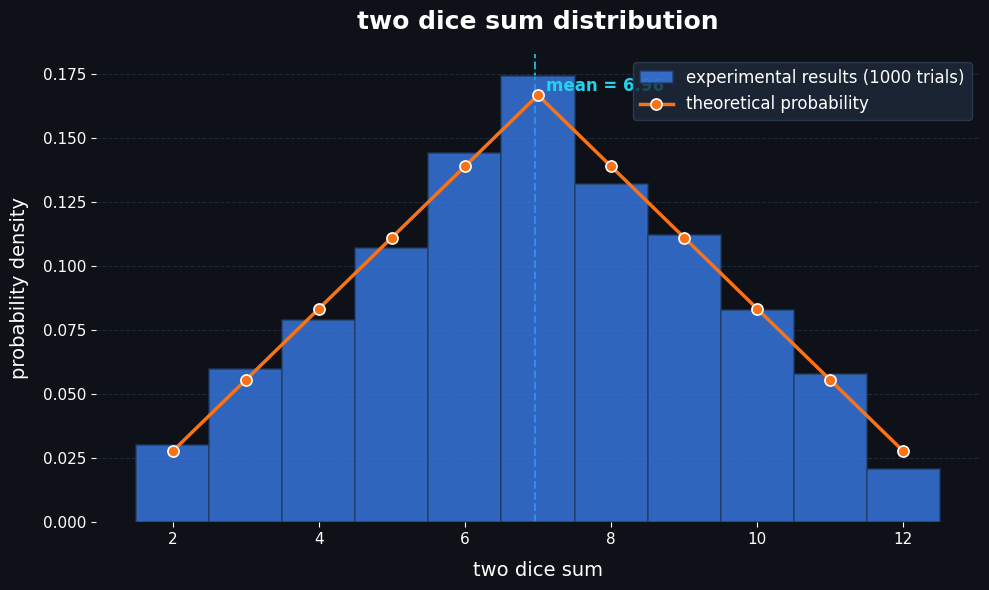

  实验次数 : 1000
  样本均值 : 6.96  (理论值 7.00)
  样本标准差: 2.40  (理论值 2.42)


In [51]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ── 模拟参数 ──
np.random.seed(42)
n_experiments = 1000

# ── 模拟掷骰子 ──
die1 = np.random.randint(1, 7, size=n_experiments)
die2 = np.random.randint(1, 7, size=n_experiments)
totals = die1 + die2 # 两个骰子点数之和

# 2=1+1
# 3=1+2,2+1
# 4=1+3,2+2,3+1
# 5=1+4,2+3,3+2,4+1
# 6=1+5,2+4,3+3,4+2,5+1
# 7=1+6,2+5,3+4,4+3,5+2,6+1
# 8=2+6,3+5,4+4,5+3,6+2
# 9=3+6,4+5,5+4,6+3
# 10=4+6,5+5,6+4
# 11=5+6,6+5
# 12=6+6
theoretical = np.array([1, 2, 3, 4, 5, 6, 5, 4, 3, 2, 1], dtype=float)
theoretical /= theoretical.sum() # 理论概率
print(f"理论概率: {theoretical}")


x_theory = np.arange(2, 13)

# ── 绘图 ──
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#0e1117")
ax.set_facecolor("#0e1117")

# 直方图（实验结果）
bins = np.arange(1.5, 13.5, 1)

# 根据totals绘制直方图,返回直方图的bin高度、bin中心、patch对象
counts, b, patches = ax.hist(
    totals, bins=bins, density=True,
    color="#3b82f6", edgecolor="#1e3a5f", linewidth=1.2,
    alpha=0.75, label=f"experimental results ({n_experiments} trials)",
    zorder=3
)
print(f"理论概率: {[f'{p:.3f}' for p in theoretical]}")
print(f"实验概率: {counts}")



# 叠加理论曲线
ax.plot(
    x_theory, theoretical,
    color="#f97316", marker="o", markersize=8,
    linewidth=2.5, markeredgecolor="white", markeredgewidth=1.2,
    label="theoretical probability", zorder=4
)

# ── 样式 ──
ax.set_xlabel("two dice sum", fontsize=14, color="white", labelpad=10)
ax.set_ylabel("probability density", fontsize=14, color="white", labelpad=10)
ax.set_title(
    "two dice sum distribution",
    fontsize=18, color="white", fontweight="bold", pad=18,
)

ax.set_xticks(x_theory)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.tick_params(colors="white", labelsize=11)
ax.spines[:].set_visible(False)
ax.grid(axis="y", color="#1e293b", linewidth=0.8, linestyle="--")
ax.legend(
    fontsize=12, facecolor="#1e293b", edgecolor="#334155",
    labelcolor="white", loc="upper right",
)


# 标注均值
mean_val = np.mean(totals)
ax.axvline(mean_val, color="#22d3ee", linestyle="--", linewidth=1.5, alpha=0.8)
ax.text(
    mean_val + 0.15, ax.get_ylim()[1] * 0.92,
    f"mean = {mean_val:.2f}",
    fontsize=12, color="#22d3ee", fontweight="bold",
)

plt.tight_layout()
# plt.savefig("dice_simulation.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

# ── 打印统计摘要 ──
print("=" * 40)
print(f"  实验次数 : {n_experiments}")
print(f"  样本均值 : {mean_val:.2f}  (理论值 7.00)")
print(f"  样本标准差: {np.std(totals):.2f}  (理论值 2.42)")
print("=" * 40)


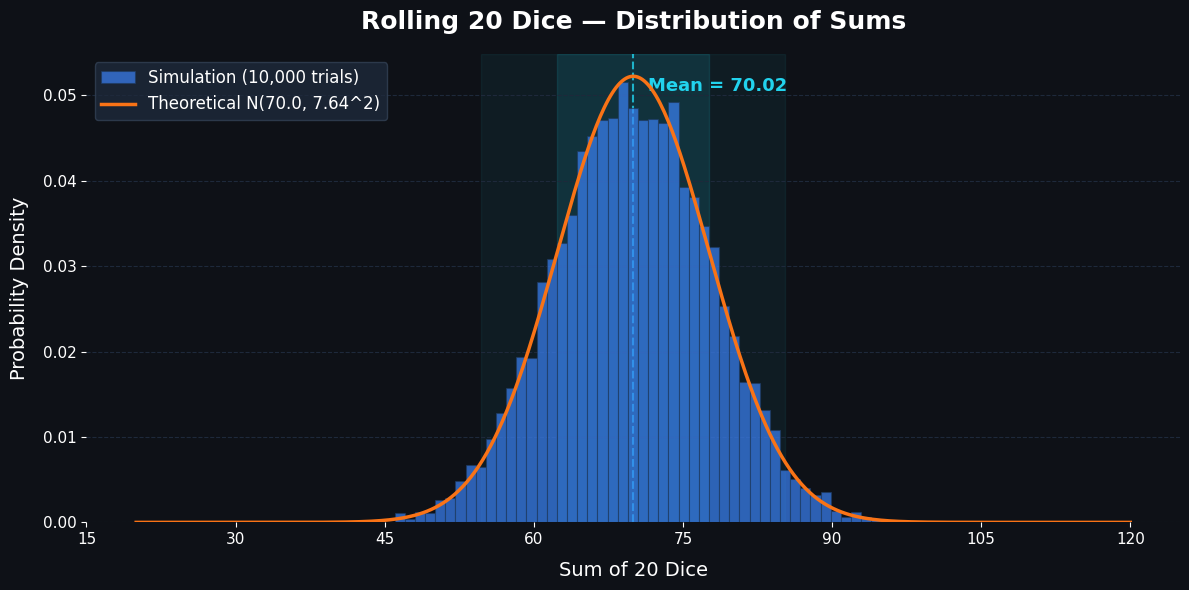

  Dice count     : 20
  Trials         : 10,000
  Sample mean    : 70.02  (theoretical 70.0)
  Sample std dev : 7.65  (theoretical 7.64)
  Range          : 46 ~ 97


In [53]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ── 模拟参数 ──
np.random.seed(42)
n_dice = 20
n_experiments = 10000

# ── 模拟掷骰子 ──
rolls = np.random.randint(1, 7, size=(n_experiments, n_dice))
totals = rolls.sum(axis=1)

# ── 理论正态分布（中心极限定理）──
mu = n_dice * 3.5
sigma = np.sqrt(n_dice * 35 / 12)
x_norm = np.linspace(n_dice, n_dice * 6, 500)
y_norm = (1 / (sigma * np.sqrt(2 * np.pi))) * \
         np.exp(-0.5 * ((x_norm - mu) / sigma) ** 2)

# ── 绘图 ──
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#0e1117")
ax.set_facecolor("#0e1117")

# 直方图
ax.hist(
    totals, bins=50, density=True,
    color="#3b82f6", edgecolor="#1e3a5f", linewidth=0.8,
    alpha=0.7, label=f"Simulation ({n_experiments:,} trials)",
    zorder=3,
)

# 叠加理论正态曲线
ax.plot(
    x_norm, y_norm,
    color="#f97316", linewidth=2.5,
    label=f"Theoretical N({mu}, {sigma:.2f}^2)",
    zorder=4,
)

# 均值竖线
ax.axvline(mu, color="#22d3ee", linestyle="--", linewidth=1.5, alpha=0.8)
ax.text(
    mu + 1.5, ax.get_ylim()[1] * 0.92,
    f"Mean = {np.mean(totals):.2f}",
    fontsize=13, color="#22d3ee", fontweight="bold",
)

# ±1σ / ±2σ 区域
for i, alpha_fill in [(1, 0.12), (2, 0.06)]:
    ax.axvspan(mu - i * sigma, mu + i * sigma,
               color="#22d3ee", alpha=alpha_fill, zorder=1)

# ── 样式 ──
ax.set_xlabel(f"Sum of {n_dice} Dice", fontsize=14, color="white", labelpad=10)
ax.set_ylabel("Probability Density", fontsize=14, color="white", labelpad=10)
ax.set_title(
    f"Rolling {n_dice} Dice — Distribution of Sums",
    fontsize=18, color="white", fontweight="bold", pad=18,
)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.tick_params(colors="white", labelsize=11)
ax.spines[:].set_visible(False)
ax.grid(axis="y", color="#1e293b", linewidth=0.8, linestyle="--")
ax.legend(
    fontsize=12, facecolor="#1e293b", edgecolor="#334155",
    labelcolor="white", loc="upper left",
)

plt.tight_layout()
# plt.savefig("dice_20_simulation.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

# ── 打印统计摘要 ──
print("=" * 45)
print(f"  Dice count     : {n_dice}")
print(f"  Trials         : {n_experiments:,}")
print(f"  Sample mean    : {np.mean(totals):.2f}  (theoretical {mu})")
print(f"  Sample std dev : {np.std(totals):.2f}  (theoretical {sigma:.2f})")
print(f"  Range          : {totals.min()} ~ {totals.max()}")
print("=" * 45)
